In [8]:
# Analisis Exploratorio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(
    'GRD.csv',
    encoding='latin-1',
    engine='python',            # use python parser which is more forgiving         
    sep=';'                 # uncomment/adjust if the file uses a different separator
)

df.head()

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,NaN,23/3/2024,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,NaN
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,NaN,NaN,78588090,NaN,41023,"58,207",3,3,NaN
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,NaN,26/1/2024,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,NaN,8/4/2024,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,NaN
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,NaN,24/9/2024,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,NaN


In [3]:
df.describe()

,COD_HOSPITAL,CONDICIONDEALTANEONATO1,PESORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,RN3ESTADO,...,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,MEDICOALTA_ENCRIPTADO,USOSPABELLON
count,1.048575e+06,0.0,115509.000000,94465.000000,0.0,1271.000000,1271.000000,0.0,14.000000,14.000000,...,31350.000000,27361.000000,23976.000000,21006.000000,18246.000000,15998.000000,5.965560e+05,0.0,1.048575e+06,632588.000000
mean,1.145591e+05,NaN,3165.667446,9.050410,NaN,2247.132179,8.597168,NaN,1669.857143,7.571429,...,87.950017,87.984653,87.937450,87.863337,88.050582,87.678529,8.186836e+07,NaN,8.332225e+07,1.388148
std,1.078535e+04,NaN,668.603935,1.066989,NaN,622.546909,1.712334,NaN,612.614555,2.651974,...,18.119481,18.110664,18.078913,18.215817,17.824472,18.591029,9.368093e+06,NaN,9.589202e+06,0.863163
min,1.011000e+05,NaN,100.000000,0.000000,NaN,200.000000,0.000000,NaN,100.000000,0.000000,...,0.140000,0.130000,0.090000,0.120000,0.090000,0.120000,6.698964e+07,NaN,6.698964e+07,0.000000
25%,1.091000e+05,NaN,2855.000000,9.000000,NaN,1902.500000,9.000000,NaN,1545.000000,8.000000,...,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,7.366486e+07,NaN,7.515274e+07,1.000000
50%,1.141010e+05,NaN,3250.000000,9.000000,NaN,2330.000000,9.000000,NaN,1845.000000,8.500000,...,91.390000,91.390000,91.390000,91.390000,91.350000,91.330000,8.075476e+07,NaN,8.269954e+07,1.000000
75%,1.181050e+05,NaN,3590.000000,9.000000,NaN,2687.500000,9.000000,NaN,2055.000000,9.000000,...,96.390000,96.350000,96.350000,96.350000,96.350000,96.350000,8.763694e+07,NaN,9.167102e+07,1.000000
max,2.007170e+05,NaN,9730.000000,11.000000,NaN,3960.000000,10.000000,NaN,2315.000000,10.000000,...,99.940000,99.980000,99.990000,99.840000,99.980000,99.840000,1.022333e+08,NaN,1.022985e+08,8.000000


In [4]:
# 1. Eliminar columnas que solo tienen valores NaN
df1 = df.dropna(axis=1, how='all').copy()

# 2. USOSPABELLON: NaN -> 0
df1['USOSPABELLON'] = df1['USOSPABELLON'].fillna(0)

# 3. HOSPPROCEDENCIA (hospital de procedencia): NaN -> "sin especificar"
df1['HOSPPROCEDENCIA'] = df1['HOSPPROCEDENCIA'].fillna('SIN ESPECIFICAR')

# 4. Excluir registros con sexo desconocido
df1['SEXO'] = df1['SEXO'].astype(str).str.strip().str.upper()
df1 = df1.loc[df1['SEXO'] != 'DESCONOCIDO'].copy()

# 5. Verificar nulos restantes
nulos = df1.isnull().sum()
print('Columnas eliminadas (solo NaN):', set(df.columns) - set(df1.columns))
print('\nNulos restantes:')
print(nulos[nulos > 0])
df1.head(50)

Columnas eliminadas (solo NaN): {'CONDICIONDEALTANEONATO4', 'CONDICIONDEALTANEONATO2', 'FECHAPROCEDIMIENTO1', 'PESORN4', 'SEXORN4', 'CONDICIONDEALTANEONATO1', 'RN4ESTADO', 'CONDICIONDEALTANEONATO3'}

Nulos restantes:
FECHATRASLADO1               880968
SERVICIOTRASLADO1            880968
FECHATRASLADO2               993217
SERVICIOTRASLADO2            993217
FECHATRASLADO3              1031895
                             ...   
PROCEDIMIENTO29             1030215
PROCEDIMIENTO30             1032463
MEDICOINTERV1_ENCRIPTADO     451955
FECHAINTERV1                 519385
ESPECIALIDADINTERVENCION     450370
Length: 94, dtype: int64


,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,MEDICOINTERV1_ENCRIPTADO,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,71043147.0,23/3/2024,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,SIN ESPECIFICAR
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,NaN,NaN,78588090,0.0,41023,"58,207",3,3,SIN ESPECIFICAR
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,71831896.0,26/1/2024,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,80215470.0,8/4/2024,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,SIN ESPECIFICAR
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,98438434.0,24/9/2024,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,SIN ESPECIFICAR
5,119101,77290150,MUJER,31/5/1983,NINGUNO,CONCEPCION,TOME,CHILE,FONASA INSTITUCIONAL - (MAI) D,TALCAHUANO,...,83916331.0,5/1/2024,OBSTETRICIA Y GINECOLOGÍA,83916331,1.0,132210,"0,9538",0,0,SIN ESPECIFICAR
6,118100,68254315,MUJER,12/1/1967,NINGUNO,CONCEPCION,CONCEPCIÓN,CHILE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,...,NaN,NaN,NaN,98438434,3.0,74143,"11,495",3,2,SIN ESPECIFICAR
7,108100,79566233,HOMBRE,4/12/1950,NINGUNO,SAN FELIPE,SAN FELIPE,CHILE,FONASA LIBRE ELECCIÓN (FMLE_B),ACONCAGUA,...,68461249.0,31/8/2024,CIRUGÍA GENERAL,68461249,1.0,62140,"0,6255",0,0,SIN ESPECIFICAR
8,126100,73275789,MUJER,21/7/1970,NINGUNO,MAGALLANES,PUNTA ARENAS,CHILE,FONASA INSTITUCIONAL - (MAI) B,MAGALLANES,...,74233756.0,3/1/2024,OBSTETRICIA Y GINECOLOGÍA,77262812,1.0,131301,"0,6406",1,1,HOSPITAL DR. LAUTARO NAVARRO AVARIA (PUNTA ARE...
9,126100,73300811,MUJER,8/1/1997,NINGUNO,MAGALLANES,PUNTA ARENAS,CHILE,FONASA INSTITUCIONAL - (MAI) D,MAGALLANES,...,NaN,NaN,NaN,69641433,0.0,134151,"0,1799",1,1,HOSPITAL DR. LAUTARO NAVARRO AVARIA (PUNTA ARE...


In [5]:
REGIONES_Y_PROVINCIAS = {
    "Arica y Parinacota": ["ARICA", "PARINACOTA"],
    "Tarapacá": ["IQUIQUE", "TAMARUGAL"],
    "Antofagasta": ["ANTOFAGASTA", "EL LOA", "TOCOPILLA"],
    "Atacama": ["COPIAPO", "CHAÑARAL", "HUASCO"],
    "Coquimbo": ["ELQUI", "LIMARI", "CHOAPA"],
    "Valparaíso": [
        "PETORCA",
        "LOS ANDES",
        "SAN FELIPE",
        "MARGA MARGA",
        "QUILLOTA",
        "VALPARAISO",
        "SAN ANTONIO",
        "ISLA DE PASCUA",
    ],
    "Metropolitana": ["SANTIAGO", "CORDILLERA", "CHACABUCO", "MAIPO", "MELIPILLA", "TALAGANTE"],
    "O'Higgins": ["CACHAPOAL", "CARDENAL CARO", "COLCHAGUA"],
    "Maule": ["TALCA", "CAUQUENES", "CURICO", "LINARES"],
    "Ñuble": ["DIGUILLÍN", "DIGUILLIN", "PUNILLA", "ITATA"],
    "Biobío": ["CONCEPCION", "ARAUCO", "BIO-BIO", "BIO BIO"],
    "La Araucanía": ["MALLECO", "CAUTIN"],
    "Los Ríos": ["VALDIVIA", "RANCO"],
    "Los Lagos": ["LLANQUIHUE", "OSORNO", "CHILOE", "CHILOÉ", "PALENA"],
    "Aysén": ["COIHAIQUE", "AISEN", "GENERAL CARRERA", "CAPITAN PRAT"],
    "Magallanes": [
        "MAGALLANES",
        "ULTIMA ESPERANZA",
        "TIERRA DEL FUEGO",
        "ANTÁRTICA CHILENA",
        "ANTARTICA CHILENA",
    ],
}

PROVINCIA_A_REGION = {
    prov.strip().upper(): region
    for region, lista in REGIONES_Y_PROVINCIAS.items()
    for prov in lista
}

df1["REGION"] = (
    df1["PROVINCIA"].astype(str).str.strip().str.upper().map(PROVINCIA_A_REGION)
)
sin_region = df1["REGION"].isna().sum()
if sin_region:
    print(
        f"Se excluyen {sin_region} filas con provincia desconocida o no mapeable a región. Ejemplos:"
    )
    print(df1.loc[df1["REGION"].isna(), "PROVINCIA"].value_counts().head(10))

df1 = df1.loc[df1["REGION"].notna()].copy()

Se excluyen 378 filas con provincia desconocida o no mapeable a región. Ejemplos:
PROVINCIA
DESCONOCIDO    378
Name: count, dtype: int64


In [6]:
df1.describe()

,COD_HOSPITAL,PESORN1,RN1ESTADO,PESORN2,RN2ESTADO,PESORN3,RN3ESTADO,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO11,...,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,MEDICOALTA_ENCRIPTADO,USOSPABELLON
count,1.048083e+06,115473.000000,94439.000000,1271.000000,1271.000000,14.000000,14.000000,465695.000000,394892.000000,275018.000000,...,35730.000000,31345.000000,27356.000000,23971.000000,21002.000000,18243.000000,15995.000000,5.962820e+05,1.048083e+06,1.048083e+06
mean,1.145587e+05,3165.701203,9.050371,2247.132179,8.597168,1669.857143,7.571429,89.528299,89.411351,89.040725,...,87.922182,87.949324,87.983967,87.939165,87.862791,88.050176,87.677395,8.186952e+07,8.332391e+07,8.375091e-01
std,1.078707e+04,668.532372,1.066607,622.546909,1.712334,612.614555,2.651974,16.098556,16.000842,16.332722,...,18.284731,18.120785,18.112225,18.078128,18.217508,17.825908,18.592494,9.368139e+06,9.589203e+06,9.543145e-01
min,1.011000e+05,100.000000,0.000000,200.000000,0.000000,100.000000,0.000000,0.090000,0.010000,0.010000,...,0.120000,0.140000,0.130000,0.090000,0.120000,0.090000,0.120000,6.698964e+07,6.698964e+07,0.000000e+00
25%,1.091000e+05,2855.000000,9.000000,1902.500000,9.000000,1545.000000,8.000000,89.520000,89.520000,89.520000,...,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,7.366486e+07,7.515361e+07,0.000000e+00
50%,1.141010e+05,3250.000000,9.000000,2330.000000,9.000000,1845.000000,8.500000,91.390000,91.390000,91.390000,...,91.390000,91.390000,91.390000,91.390000,91.390000,91.350000,91.330000,8.075476e+07,8.270030e+07,1.000000e+00
75%,1.181050e+05,3590.000000,9.000000,2687.500000,9.000000,2055.000000,9.000000,99.190000,99.180000,97.690000,...,96.570000,96.390000,96.350000,96.350000,96.350000,96.350000,96.350000,8.763694e+07,9.167190e+07,1.000000e+00
max,2.007170e+05,9730.000000,11.000000,3960.000000,10.000000,2315.000000,10.000000,99.990000,99.990000,99.990000,...,99.980000,99.940000,99.980000,99.990000,99.840000,99.980000,99.840000,1.022333e+08,1.022985e+08,8.000000e+00


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1048083 entries, 0 to 1048574
Columns: 122 entries, COD_HOSPITAL to REGION
dtypes: float64(28), int64(2), object(92)
memory usage: 983.5+ MB


In [8]:
df_maestras = pd.read_excel('Tablas maestras bases GRD.xlsx', engine='openpyxl')
df1['COD_HOSPITAL'] = df1['COD_HOSPITAL'].astype(str).str.strip()
df_maestras['COD_HOSPITAL'] = df_maestras['COD_HOSPITAL'].astype(str).str.strip()

df_final = df1.merge(df_maestras[['COD_HOSPITAL', 'NOM_HOSPITAL']], on='COD_HOSPITAL', how='left')

In [9]:
df_final.head()

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA,REGION,NOM_HOSPITAL
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,SIN ESPECIFICAR,Valparaíso,Hospital de Quilpué
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,78588090,0.0,41023,"58,207",3,3,SIN ESPECIFICAR,Valparaíso,Hospital Dr. Gustavo Fricke (Viña del Mar)
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO),Coquimbo,Hospital San Pablo (Coquimbo)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,SIN ESPECIFICAR,Metropolitana,"Hospital Del Salvador (Santiago, Providencia)"
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,SIN ESPECIFICAR,Biobío,Hospital Clínico Regional Dr. Guillermo Grant ...


In [10]:
cols = ['SEXO', 'REGION', 'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'FECHA_INGRESO', 'FECHA_NACIMIENTO']
df_etario = df1[cols].copy()

df_etario['FECHA_INGRESO'] = pd.to_datetime(df_etario['FECHA_INGRESO'], errors='coerce', dayfirst=True)
df_etario['FECHA_NACIMIENTO'] = pd.to_datetime(df_etario['FECHA_NACIMIENTO'], errors='coerce', dayfirst=True)
df_etario = df_etario.dropna(subset=['FECHA_INGRESO', 'FECHA_NACIMIENTO'])

df_etario['EDAD'] = (df_etario['FECHA_INGRESO'].dt.year - df_etario['FECHA_NACIMIENTO'].dt.year).astype(int)
df_etario['EDAD'] = df_etario['EDAD'].clip(0, 120)
df_etario['IR_29301_SEVERIDAD'] = pd.to_numeric(df_etario['IR_29301_SEVERIDAD'], errors='coerce')
df_etario['IR_29301_MORTALIDAD'] = pd.to_numeric(df_etario['IR_29301_MORTALIDAD'], errors='coerce')
df_etario['SEXO'] = df_etario['SEXO'].astype(str).str.strip().str.upper()

df_etario['EDAD_TRAMO'] = pd.cut(
    df_etario['EDAD'],
    bins=[-1, 17, 39, 64, 200],
    labels=['0-17', '18-39', '40-64', '65+'],
)

promedio_por_region_edad_sexo = (
    df_etario.groupby(['REGION', 'EDAD_TRAMO', 'SEXO'], observed=True)
    .agg(
        n_casos=('IR_29301_SEVERIDAD', 'count'),
        severidad_promedio=('IR_29301_SEVERIDAD', 'mean'),
        mortalidad_promedio=('IR_29301_MORTALIDAD', 'mean'),
    )
    .reset_index()
    .sort_values(['REGION', 'EDAD_TRAMO', 'SEXO'])
)


promedio_por_region_edad_sexo

,REGION,EDAD_TRAMO,SEXO,n_casos,severidad_promedio,mortalidad_promedio
0,Antofagasta,0-17,HOMBRE,3167,1.410167,1.206189
1,Antofagasta,0-17,MUJER,2470,1.532389,1.297166
2,Antofagasta,18-39,HOMBRE,2452,1.310359,1.208809
3,Antofagasta,18-39,MUJER,8050,1.182360,1.013789
4,Antofagasta,40-64,HOMBRE,3830,1.565535,1.530548
...,...,...,...,...,...,...
123,Ñuble,18-39,MUJER,6194,1.260090,0.997417
124,Ñuble,40-64,HOMBRE,4355,1.443398,1.356372
125,Ñuble,40-64,MUJER,5145,1.243926,1.117590
126,Ñuble,65+,HOMBRE,5627,1.667851,1.593389


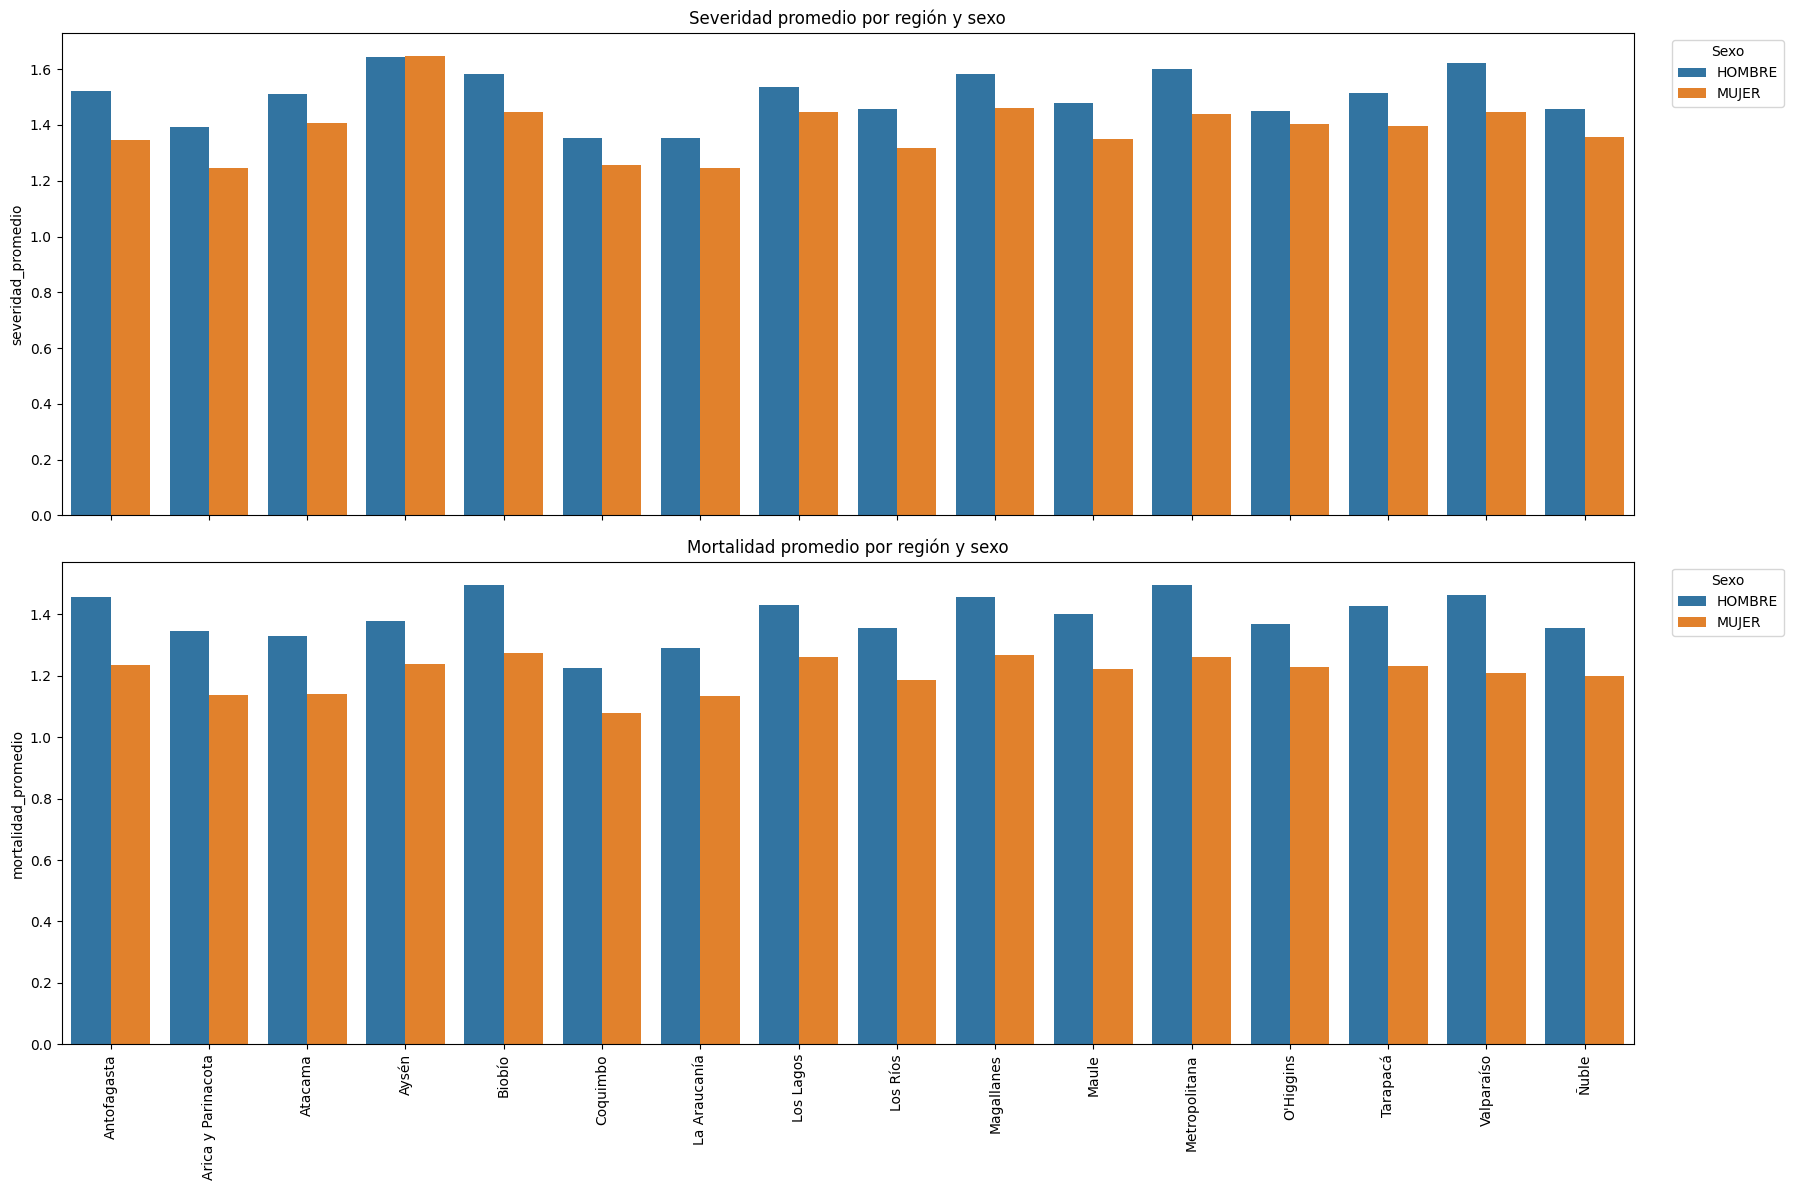

In [11]:
agg_prov_sexo = (
    df_etario.groupby(['REGION', 'SEXO'], observed=True)
    .agg(
        severidad_promedio=('IR_29301_SEVERIDAD', 'mean'),
        mortalidad_promedio=('IR_29301_MORTALIDAD', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)
sns.barplot(
    data=agg_prov_sexo,
    x='REGION',
    y='severidad_promedio',
    hue='SEXO',
    ax=axes[0],
)
axes[0].set_title('Severidad promedio por región y sexo')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Sexo', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.barplot(
    data=agg_prov_sexo,
    x='REGION',
    y='mortalidad_promedio',
    hue='SEXO',
    ax=axes[1],
)
axes[1].set_title('Mortalidad promedio por región y sexo')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Sexo', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [12]:
# Agrupar por sexo, provincia y severidad
resumen = df_final.groupby(['SEXO', 'REGION', 'IR_29301_SEVERIDAD']).size().reset_index(name='TOTAL_CASOS')

# Ordenar los resultados para que sea más fácil de leer
resumen = resumen.sort_values(by=['REGION', 'TOTAL_CASOS'], ascending=[True, False])


print(f"Total de filas en el resumen (combinaciones sexo×provincia×severidad): {len(resumen)}")
print(f"Regiones distintas en la base: {resumen['REGION'].nunique()}")
print("(Las primeras filas son solo AISEN porque el orden es alfabético por provincia, no porque exista una sola.)\n")
print(resumen.head(12))

Total de filas en el resumen (combinaciones sexo×provincia×severidad): 130
Regiones distintas en la base: 16
(Las primeras filas son solo AISEN porque el orden es alfabético por provincia, no porque exista una sola.)

      SEXO              REGION IR_29301_SEVERIDAD  TOTAL_CASOS
66   MUJER         Antofagasta                  1        10242
1   HOMBRE         Antofagasta                  1         5633
67   MUJER         Antofagasta                  2         4136
2   HOMBRE         Antofagasta                  2         3099
3   HOMBRE         Antofagasta                  3         2820
68   MUJER         Antofagasta                  3         2591
65   MUJER         Antofagasta                  0         2578
0   HOMBRE         Antofagasta                  0         1796
70   MUJER  Arica y Parinacota                  1         6291
5   HOMBRE  Arica y Parinacota                  1         4024
71   MUJER  Arica y Parinacota                  2         2138
69   MUJER  Arica y Parina

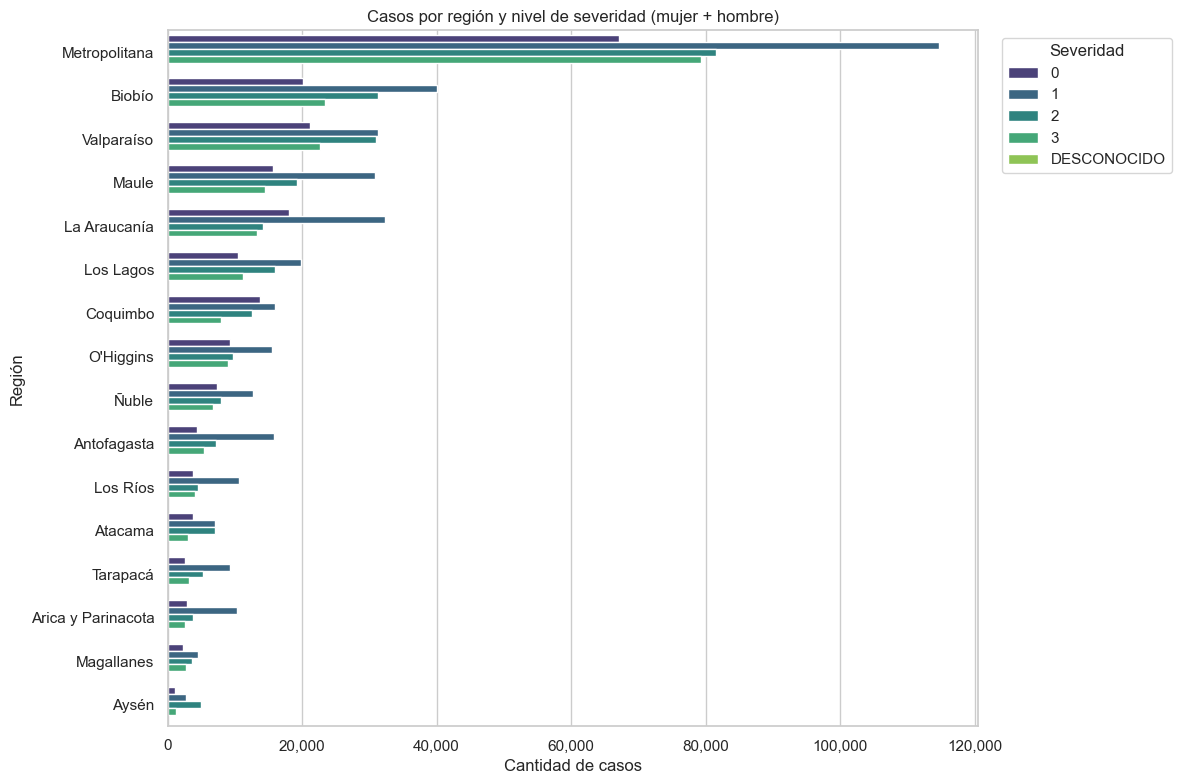

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Una fila por región × severidad (sumar mujer + hombre; barplot no debe promediar por sexo)
plot_df = (
    resumen.groupby(["REGION", "IR_29301_SEVERIDAD"], as_index=False)["TOTAL_CASOS"]
    .sum()
)
orden_regiones = (
    plot_df.groupby("REGION")["TOTAL_CASOS"]
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

sns.set_theme(style="whitegrid")
alto = max(8.0, len(orden_regiones) * 0.5)
fig, ax = plt.subplots(figsize=(12, alto))

sns.barplot(
    data=plot_df,
    y="REGION",
    x="TOTAL_CASOS",
    hue="IR_29301_SEVERIDAD",
    order=orden_regiones,
    palette="viridis",
    ax=ax,
)

ax.set_title("Casos por región y nivel de severidad (mujer + hombre)")
ax.set_xlabel("Cantidad de casos")
ax.set_ylabel("Región")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(title="Severidad", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
fig.tight_layout()

plt.show()

# Analisis de tendencia

In [14]:
print(list(df_final.columns))

['COD_HOSPITAL', 'ID_BENEFICIARIO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'TIPO_ACTIVIDAD', 'FECHA_INGRESO', 'SERVICIOINGRESO', 'FECHATRASLADO1', 'SERVICIOTRASLADO1', 'FECHATRASLADO2', 'SERVICIOTRASLADO2', 'FECHATRASLADO3', 'SERVICIOTRASLADO3', 'FECHATRASLADO4', 'SERVICIOTRASLADO4', 'FECHATRASLADO5', 'SERVICIOTRASLADO5', 'FECHATRASLADO6', 'SERVICIOTRASLADO6', 'FECHATRASLADO7', 'SERVICIOTRASLADO7', 'FECHATRASLADO8', 'SERVICIOTRASLADO8', 'FECHATRASLADO9', 'SERVICIOTRASLADO9', 'FECHAALTA', 'SERVICIOALTA', 'TIPOALTA', 'PESORN1', 'SEXORN1', 'RN1ESTADO', 'PESORN2', 'SEXORN2', 'RN2ESTADO', 'PESORN3', 'SEXORN3', 'RN3ESTADO', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOSTICO7', 'DIAGNOSTICO8', 'DIAGNOSTICO9', 'DIAGNOSTICO10', 'DIAGNOSTICO11', 'DIAGNOSTICO12', 'DIAGNOSTICO13', 'DIAGNOSTICO14', 'DIAGNOSTICO15', '

## Variables:

Edad
Sexo
Patologías

Encontrar un patron del perfil de pacientes los costos más elevados. El costo lo podemos inferir en base al tiempo de hospitalización, intervención y especialidad. Sin importar tramo de fonasa, el valor de cuanto costaría. Predecir el costo. 


In [15]:
df_reducido = df_final.copy()

# 1. Convertir usando format='mixed' y errors='coerce'
# 'mixed' analiza cada fecha por separado por si vienen en distinto formato
# 'coerce' ignora los "DESCONOCIDO" o textos extraños
df_reducido['FECHA_INGRESO'] = pd.to_datetime(df_reducido['FECHA_INGRESO'], errors='coerce', dayfirst=True)
df_reducido['FECHAALTA'] = pd.to_datetime(df_reducido['FECHAALTA'], errors='coerce', dayfirst=True)
df_reducido['FECHA_NACIMIENTO'] = pd.to_datetime(df_reducido['FECHA_NACIMIENTO'], errors='coerce', dayfirst=True)

# 2. Limpieza CRÍTICA: Eliminar filas donde la fecha falló
# Si no borramos los NaT, la resta de fechas dará error más adelante
df_reducido = df_reducido.dropna(subset=['FECHA_INGRESO', 'FECHAALTA', 'FECHA_NACIMIENTO'])

# 3. Cálculo de Días de Estadía y Edad
# Usamos .astype(int) para asegurar que sean números limpios
df_reducido['DIAS_ESTADIA'] = (df_reducido['FECHAALTA'] - df_reducido['FECHA_INGRESO']).dt.days
df_reducido['EDAD'] = (df_reducido['FECHA_INGRESO'].dt.year - df_reducido['FECHA_NACIMIENTO'].dt.year).astype(int)

# 4. Verificación rápida: si esto imprime algo, el código funcionó
print(f"Base procesada con {len(df_reducido)} registros válidos.")
print(df_reducido[['DIAS_ESTADIA', 'EDAD']].head())

Base procesada con 1048030 registros válidos.
   DIAS_ESTADIA  EDAD
0             0    85
1             6    72
2             4    12
3             6    72
4             2    30


In [20]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats

df_anova = df_reducido[['IR_29301_PESO', 'IR_29301_SEVERIDAD']].dropna().copy()
df_anova['IR_29301_SEVERIDAD'] = df_anova['IR_29301_SEVERIDAD'].astype(int).astype('category')

# 1. Modelo ANOVA de una vía
modelo_anova = smf.ols('IR_29301_PESO ~ C(IR_29301_SEVERIDAD)', data=df_anova).fit()
tabla_anova = anova_lm(modelo_anova, typ=2)

print("ANOVA de una vía: IR_29301_PESO por nivel de severidad")
print(tabla_anova)

# 2. Medias por severidad
print("\nMedias de IR_29301_PESO por severidad:")
print(df_anova.groupby('IR_29301_SEVERIDAD')['IR_29301_PESO'].agg(['count', 'mean', 'std']))

# 3. Prueba de homogeneidad de varianzas (Levene)
grupos = [g['IR_29301_PESO'].values for _, g in df_anova.groupby('IR_29301_SEVERIDAD')]
w_stat, p_levene = stats.levene(*grupos)
print(f"\nLevene: W={w_stat:.4f}, p={p_levene:.4f}")

# 4. Normalidad de residuos (Shapiro, si la muestra no es muy grande)
residuos = modelo_anova.resid
muestra = residuos.sample(n=min(5000, len(residuos)), random_state=0)
shapiro_stat, shapiro_p = stats.shapiro(muestra)
print(f"Shapiro-Wilk residuos: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")

ANOVA de una vía: IR_29301_PESO por nivel de severidad
                             sum_sq         df             F  PR(>F)
C(IR_29301_SEVERIDAD)  3.224218e+07        3.0  95592.380654     0.0
Residual               1.178272e+08  1048011.0           NaN     NaN

Medias de IR_29301_PESO por severidad:
                     count       mean        std
IR_29301_SEVERIDAD                              
0                   204020   1.135012   3.659322
1                   373970   2.137122   4.462543
2                   259782   5.368954   7.884536
3                   210243  16.212272  20.861576

Levene: W=64279.2071, p=0.0000
Shapiro-Wilk residuos: W=0.5865, p=0.0000


/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_18069/2428486562.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_anova.groupby('IR_29301_SEVERIDAD')['IR_29301_PESO'].agg(['count', 'mean', 'std']))
/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_18069/2428486562.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos = [g['IR_29301_PESO'].values for _, g in df_anova.groupby('IR_29301_SEVERIDAD')]


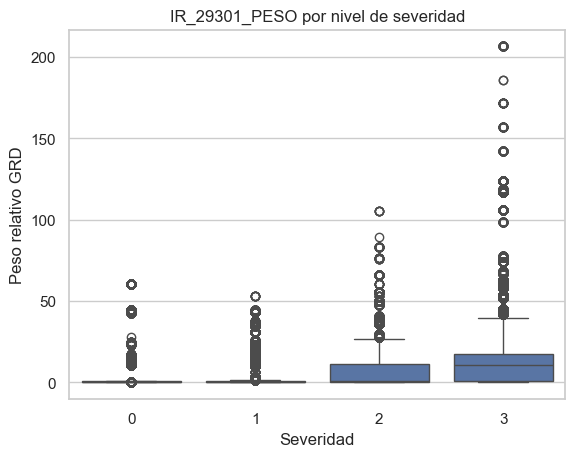

In [21]:
sns.boxplot(
    data=df_anova,
    x='IR_29301_SEVERIDAD',
    y='IR_29301_PESO',
)
plt.title('IR_29301_PESO por nivel de severidad')
plt.xlabel('Severidad')
plt.ylabel('Peso relativo GRD')
plt.show()

In [16]:
# 1. Limpiar la columna de Peso (cambiar coma por punto si existe y convertir a float)
if df_reducido['IR_29301_PESO'].dtype == 'object':
    df_reducido['IR_29301_PESO'] = df_reducido['IR_29301_PESO'].astype(str).str.replace(',', '.')
    
df_reducido['IR_29301_PESO'] = pd.to_numeric(df_reducido['IR_29301_PESO'], errors='coerce')

# 2. Asegurar que Severidad sea numérica
df_reducido['IR_29301_SEVERIDAD'] = pd.to_numeric(df_reducido['IR_29301_SEVERIDAD'], errors='coerce')

# 3. Eliminar filas donde el peso quedó vacío tras la conversión
df_reducido = df_reducido.dropna(subset=['IR_29301_PESO'])

# 4. Sociodemografía y coherencia clínica
df_reducido['SEXO'] = df_reducido['SEXO'].astype(str).str.strip().str.upper()
df_reducido['COMUNA'] = df_reducido['COMUNA'].astype(str).str.strip().str.upper()
df_reducido['COMUNA'] = df_reducido['COMUNA'].replace({'', 'NAN', 'NONE'}, np.nan).fillna('SIN INFORMAR')

# Recortar valores extremos (no eliminar filas): se conservan todos los registros con peso válido
df_reducido['DIAS_ESTADIA'] = df_reducido['DIAS_ESTADIA'].clip(lower=0)
df_reducido['EDAD'] = df_reducido['EDAD'].clip(0, 120)

# 5. Costo proxy (sin precio monetario): peso GRD × días de estadía (mín. 1 día)
df_reducido['COSTO_PROXY'] = df_reducido['IR_29301_PESO'] * np.maximum(df_reducido['DIAS_ESTADIA'], 1)

# 6. Tramos de edad para el perfil
df_reducido['EDAD_TRAMO'] = pd.cut(
    df_reducido['EDAD'],
    bins=[-1, 17, 39, 64, 200],
    labels=['0-17', '18-39', '40-64', '65+'],
)

print(f"Registros en df_reducido para análisis: {len(df_reducido):,}")
print("(Solo se excluyen filas sin fechas válidas o sin IR_29301_PESO; edad/estadía se recortan, no se borran.)")

Registros en df_reducido para análisis: 1,048,015
(Solo se excluyen filas sin fechas válidas o sin IR_29301_PESO; edad/estadía se recortan, no se borran.)


### Pregunta 2: Días de estadía vs peso GRD según severidad

Relación entre `DIAS_ESTADIA` y `IR_29301_PESO` estratificada por `IR_29301_SEVERIDAD` (regresión lineal por nivel y correlación de Pearson por grupo).

/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_18069/2974651824.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _r_por_sev = _d.groupby("IR_29301_SEVERIDAD", observed=True).apply(


Correlación Pearson(días, peso) por severidad:
IR_29301_SEVERIDAD
0    0.0416
1    0.0979
2    0.1988
3    0.4320


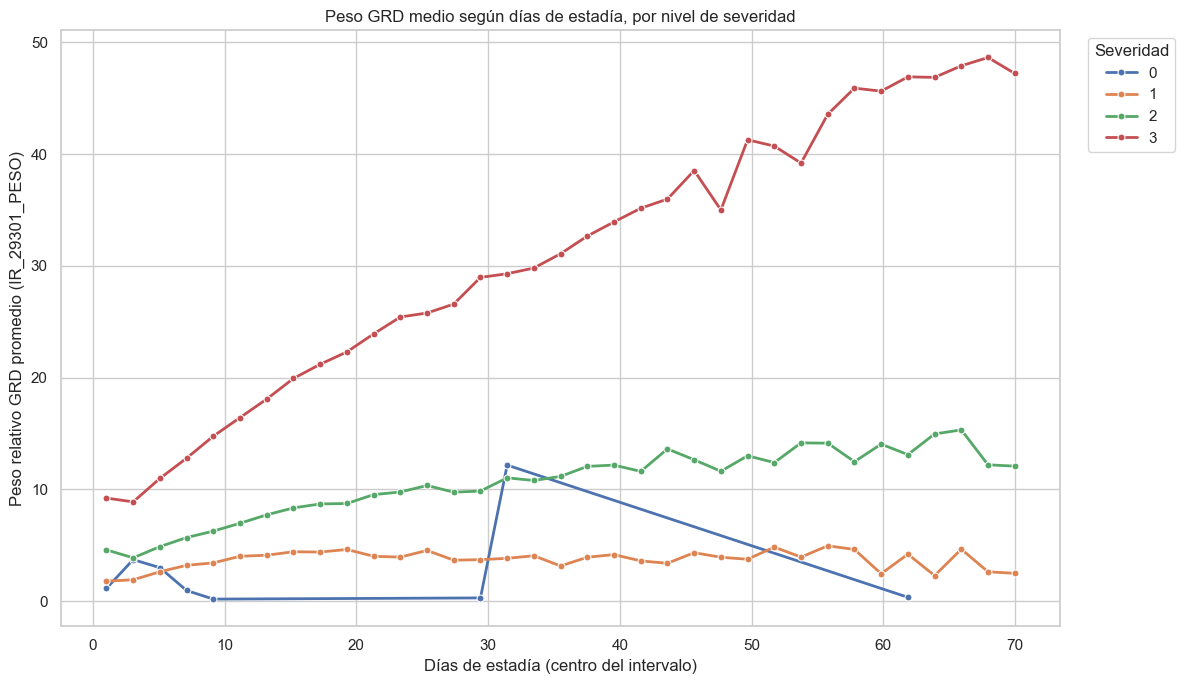

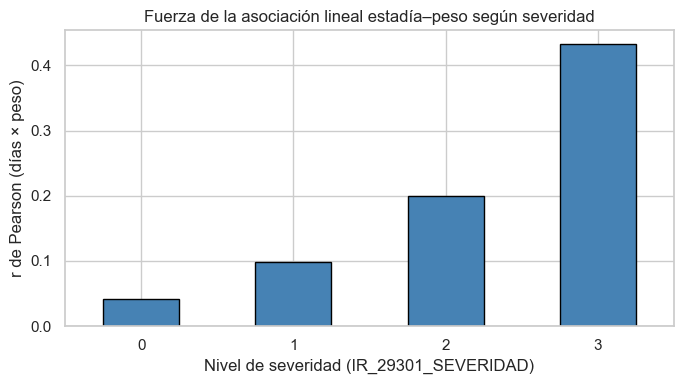

(Curvas: datos con días ≤ p99.5 (71 días); 35 intervalos de días; n registros = 1,042,818)


In [17]:
# Pregunta 2: cómo varía la relación estadía–peso GRD según severidad
_cols = ["DIAS_ESTADIA", "IR_29301_PESO", "IR_29301_SEVERIDAD"]
_d = df_reducido.dropna(subset=_cols).copy()
_d["IR_29301_SEVERIDAD"] = _d["IR_29301_SEVERIDAD"].astype(int)

# Correlación de Pearson por nivel (toda la base válida)
_r_por_sev = _d.groupby("IR_29301_SEVERIDAD", observed=True).apply(
    lambda g: g["DIAS_ESTADIA"].corr(g["IR_29301_PESO"])
)
print("Correlación Pearson(días, peso) por severidad:")
print(_r_por_sev.round(4).to_string())

# Recorte de cola de días; promedios por intervalo de días (eje X) y peso medio (eje Y)
_p99 = _d["DIAS_ESTADIA"].quantile(0.995)
_dc = _d.loc[_d["DIAS_ESTADIA"] <= _p99].copy()
_max_d = float(_dc["DIAS_ESTADIA"].max())
_n_bins = 35
_edges = np.linspace(0, _max_d, _n_bins + 1)
_dc["dias_bin"] = pd.cut(_dc["DIAS_ESTADIA"], bins=_edges, include_lowest=True)
_agg = (
    _dc.groupby(["dias_bin", "IR_29301_SEVERIDAD"], observed=False)
    .agg(peso_promedio=("IR_29301_PESO", "mean"), n=("IR_29301_PESO", "size"))
    .reset_index()
)
_agg["dias_mid"] = _agg["dias_bin"].apply(lambda iv: iv.mid if pd.notna(iv) else np.nan)
_agg["Severidad"] = _agg["IR_29301_SEVERIDAD"].astype(str)
_agg = _agg.dropna(subset=["dias_mid"])

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=_agg,
    x="dias_mid",
    y="peso_promedio",
    hue="Severidad",
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax,
    errorbar=None,
)
ax.set_xlabel("Días de estadía (centro del intervalo)")
ax.set_ylabel("Peso relativo GRD promedio (IR_29301_PESO)")
ax.set_title("Peso GRD medio según días de estadía, por nivel de severidad")
plt.legend(title="Severidad", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
_r_por_sev.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Nivel de severidad (IR_29301_SEVERIDAD)")
ax.set_ylabel("r de Pearson (días × peso)")
ax.set_title("Fuerza de la asociación lineal estadía–peso según severidad")
ax.axhline(0, color="gray", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(
    f"(Curvas: datos con días ≤ p99.5 ({_p99:.0f} días); {_n_bins} intervalos de días; n registros = {len(_dc):,})"
)


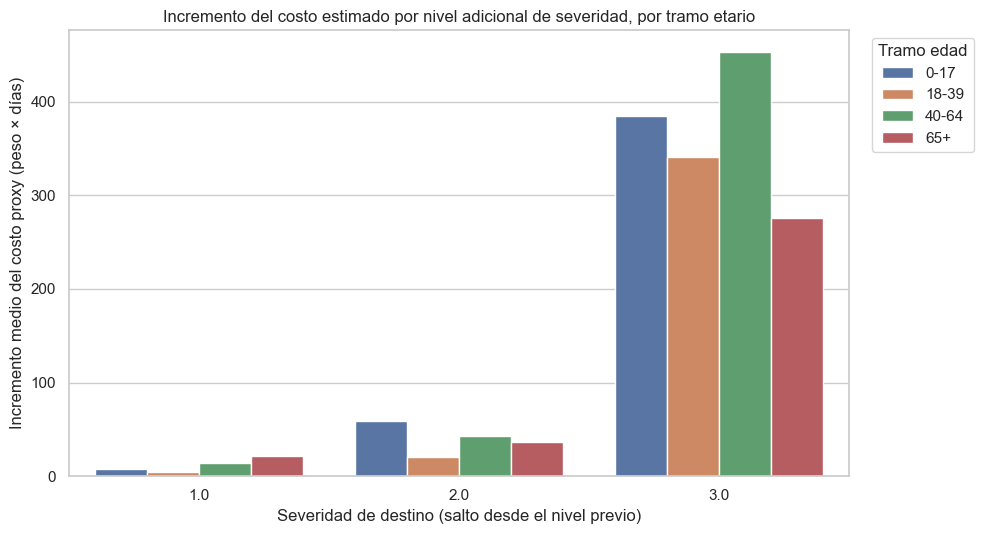

,EDAD_TRAMO,IR_29301_SEVERIDAD,costo_proxy_medio,severidad_nivel_previo,costo_medio_nivel_previo,incremento_costo_por_nivel_severidad
0,0-17,0.0,0.730744,NaN,NaN,NaN
1,0-17,1.0,8.031023,0.0,0.730744,7.300279
2,0-17,2.0,66.462750,1.0,8.031023,58.431727
3,0-17,3.0,451.385460,2.0,66.462750,384.922710
4,18-39,0.0,1.032251,NaN,NaN,NaN
5,18-39,1.0,5.515272,0.0,1.032251,4.483021
6,18-39,2.0,25.918028,1.0,5.515272,20.402756
7,18-39,3.0,367.049420,2.0,25.918028,341.131392
8,40-64,0.0,1.195832,NaN,NaN,NaN
9,40-64,1.0,15.305612,0.0,1.195832,14.109779


In [18]:
# Incremento del costo estimado (peso × días, COSTO_PROXY) al subir un nivel de severidad GRD,
# dentro del mismo tramo etario (EDAD_TRAMO).
_sev = df_reducido.dropna(subset=['IR_29301_SEVERIDAD', 'EDAD_TRAMO'])
incremento_severidad_por_edad = (
    _sev.groupby(['EDAD_TRAMO', 'IR_29301_SEVERIDAD'], observed=True)
    .agg(
        costo_proxy_medio=('COSTO_PROXY', 'mean'),
    )
    .reset_index()
    .sort_values(['EDAD_TRAMO', 'IR_29301_SEVERIDAD'])
)
_g = incremento_severidad_por_edad.groupby('EDAD_TRAMO', observed=True)
incremento_severidad_por_edad['severidad_nivel_previo'] = _g['IR_29301_SEVERIDAD'].shift(1)
incremento_severidad_por_edad['costo_medio_nivel_previo'] = _g['costo_proxy_medio'].shift(1)
incremento_severidad_por_edad['incremento_costo_por_nivel_severidad'] = (
    incremento_severidad_por_edad['costo_proxy_medio']
    - incremento_severidad_por_edad['costo_medio_nivel_previo']
)

import matplotlib.pyplot as plt
import seaborn as sns

_graf = incremento_severidad_por_edad.dropna(subset=['incremento_costo_por_nivel_severidad'])
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=_graf,
    x='IR_29301_SEVERIDAD',
    y='incremento_costo_por_nivel_severidad',
    hue='EDAD_TRAMO',
    ax=ax,
)
ax.set_xlabel('Severidad de destino (salto desde el nivel previo)')
ax.set_ylabel('Incremento medio del costo proxy (peso × días)')
ax.set_title('Incremento del costo estimado por nivel adicional de severidad, por tramo etario')
ax.legend(title='Tramo edad', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

incremento_severidad_por_edad

In [80]:
detalle_peso_region_sexo = (
    df_reducido.groupby(['REGION', 'SEXO'], observed=True)
    .agg(
        n_casos=('IR_29301_PESO', 'count'),
        peso_promedio=('IR_29301_PESO', 'mean'),
    )
    .reset_index()
    .sort_values(['REGION', 'SEXO'])
)

tabla_peso_promedio_region_x_sexo = (
    df_reducido.pivot_table(
        index='REGION',
        columns='SEXO',
        values='IR_29301_PESO',
        aggfunc='mean',
    )
    .sort_index()
    .round(4)
)

detalle_peso_region_sexo.to_csv('promedio_IR_29301_PESO_por_region_sexo_detalle.csv', index=False)
tabla_peso_promedio_region_x_sexo

SEXO,HOMBRE,MUJER
REGION,,
Antofagasta,6.7521,3.8723
Arica y Parinacota,5.9709,3.3675
Atacama,5.9281,3.8993
Aysén,6.1257,4.7183
Biobío,6.8585,4.3822
Coquimbo,6.3724,4.1861
La Araucanía,6.2545,3.8632
Los Lagos,6.7383,4.4251
Los Ríos,7.3347,4.6161


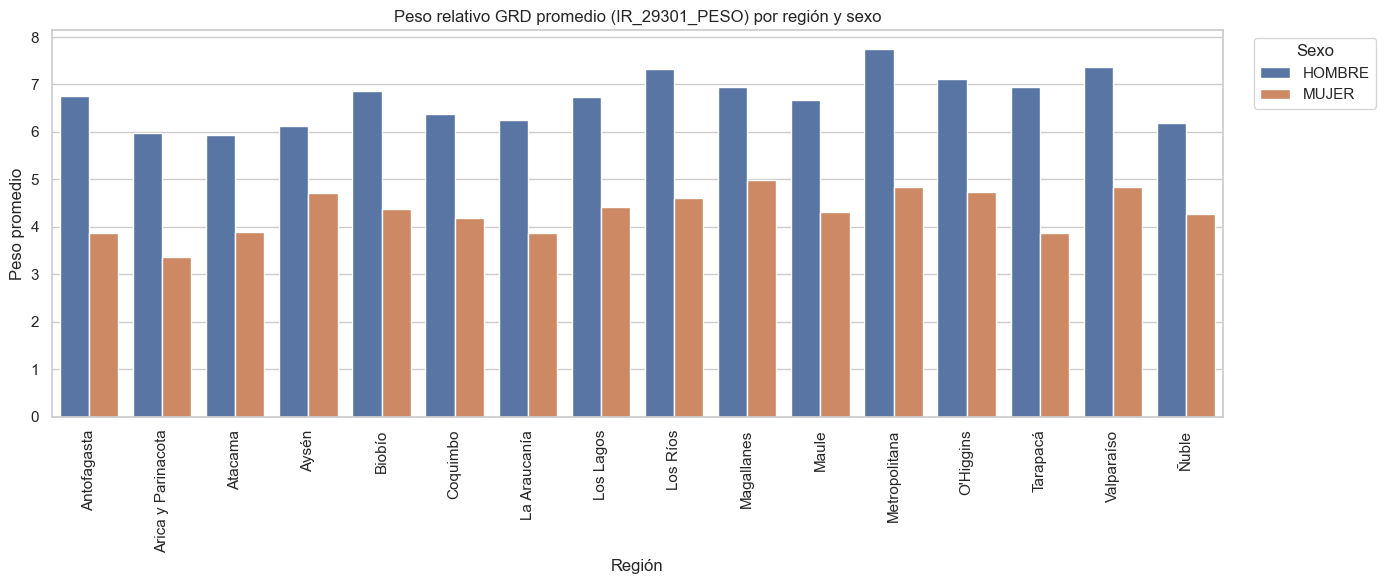

In [81]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=detalle_peso_region_sexo,
    x='REGION',
    y='peso_promedio',
    hue='SEXO',
    ax=ax,
)
ax.set_title('Peso relativo GRD promedio (IR_29301_PESO) por región y sexo')
ax.set_xlabel('Región')
ax.set_ylabel('Peso promedio')
ax.tick_params(axis='x', rotation=90)
plt.legend(title='Sexo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Top 5 por media IR (cualquier n; con pocos casos la media puede ser muy alta por azar):
                                               IR_29301_PESO   PESO_TOTAL  \
ESPECIALIDAD_MEDICA                                                         
CIRUGÍA CARDIOVASCULAR                             34.415876  213137.5230   
MEDICINA FISICA Y REHABILITACIÓN PEDIÁTRICA        25.769000      51.5380   
MEDICINA INTENSIVA ADULTO                          20.609231  259532.0459   
NEUROCIRUGÍA                                       16.583097  300253.5557   
MEDICINA FÍSICA Y REHABILITACIÓN                   15.863837    1380.1538   

                                               DIAS_ESTADIA  TOTAL_CASOS  
ESPECIALIDAD_MEDICA                                                       
CIRUGÍA CARDIOVASCULAR                            12.436622         6193  
MEDICINA FISICA Y REHABILITACIÓN PEDIÁTRICA       15.000000            2  
MEDICINA INTENSIVA ADULTO                         11.411340        12593

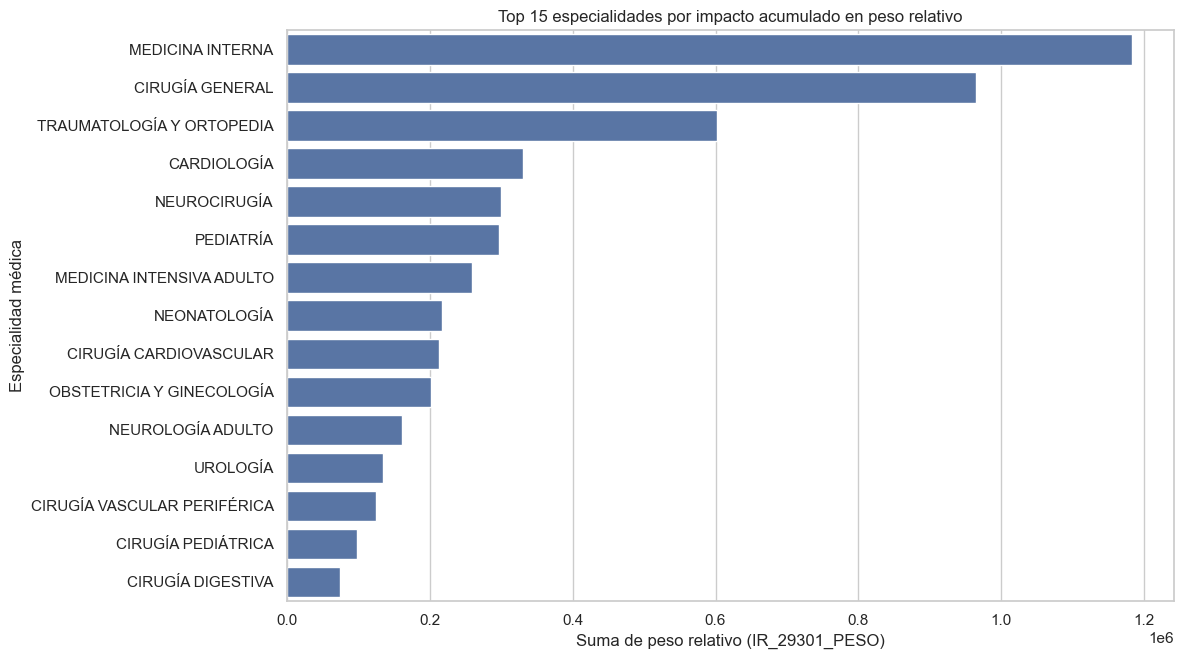

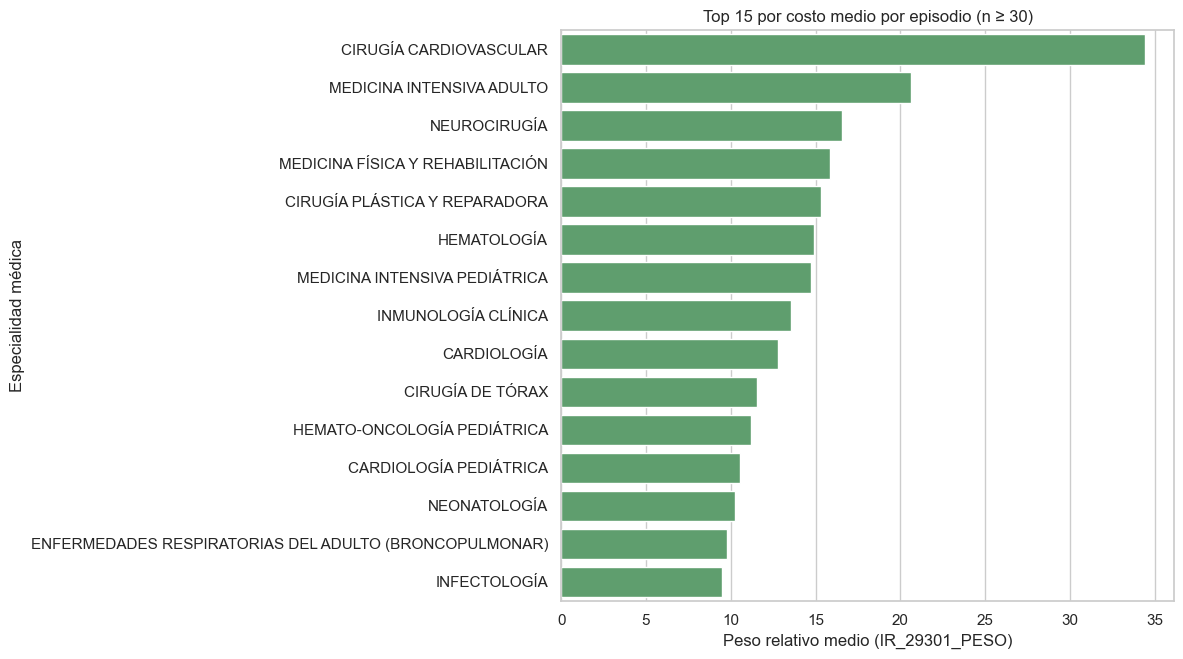


Umbrales (percentil 80): PESO >= 10.9380 ó COSTO_PROXY >= 31.75 (unión, no intersección)
Casos en subconjunto 'alto' (peso alto o costo proxy alto): 254,854 (24.32% del total)
Regiones distintas en df_reducido: 16 | en subconjunto alto: 16

Composición (%) dentro de ese subconjunto — sexo:
SEXO
HOMBRE    52.37
MUJER     47.63
Name: proportion, dtype: float64

Composición (%) — tramo de edad:
EDAD_TRAMO
65+      44.05
40-64    31.26
18-39    12.46
0-17     12.23
Name: proportion, dtype: float64

Top 15 regiones por participación relativa (%) en el subconjunto alto:
REGION
Metropolitana         34.54
Valparaíso            11.08
Biobío                10.88
Maule                  7.31
La Araucanía           6.56
Los Lagos              5.32
Coquimbo               4.58
O'Higgins              4.09
Ñuble                  3.08
Antofagasta            2.77
Los Ríos               2.32
Atacama                1.86
Tarapacá               1.67
Arica y Parinacota     1.52
Magallanes             1.40
N

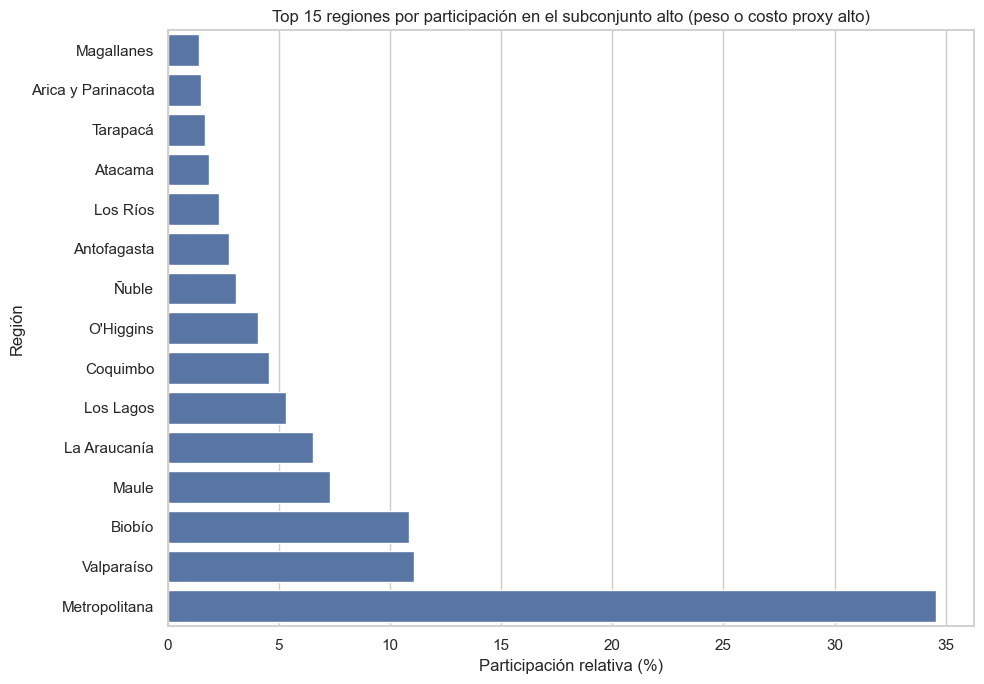

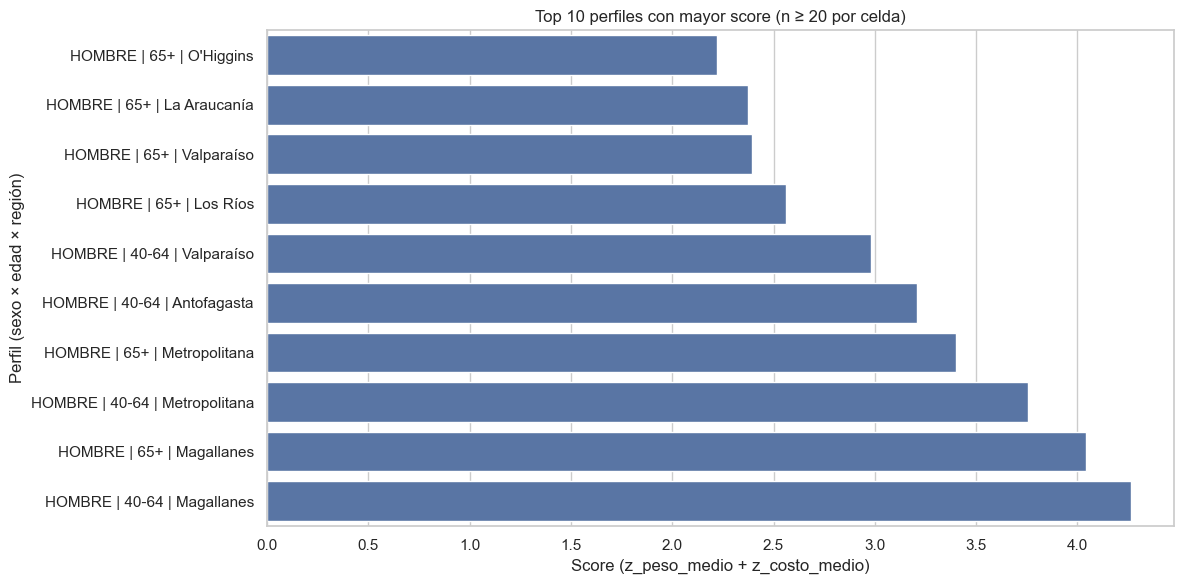

In [91]:
perfil_especialidad = df_reducido.groupby('ESPECIALIDAD_MEDICA').agg(
    IR_29301_PESO=('IR_29301_PESO', 'mean'),
    PESO_TOTAL=('IR_29301_PESO', 'sum'),
    DIAS_ESTADIA=('DIAS_ESTADIA', 'mean'),
    TOTAL_CASOS=('NOM_HOSPITAL', 'count'),
)

MIN_CASOS_ESP = 30
perfil_esp_por_media = perfil_especialidad.sort_values('IR_29301_PESO', ascending=False)
perfil_esp_estable = (
    perfil_especialidad.loc[perfil_especialidad['TOTAL_CASOS'] >= MIN_CASOS_ESP]
    .sort_values('IR_29301_PESO', ascending=False)
)
perfil_esp_impacto = perfil_especialidad.sort_values('PESO_TOTAL', ascending=False)

print("Top 5 por media IR (cualquier n; con pocos casos la media puede ser muy alta por azar):")
print(perfil_esp_por_media.head(5))
print(f"\nTop 5 por media IR con n >= {MIN_CASOS_ESP}:")
print(perfil_esp_estable.head(5))
print("\nTop 5 por impacto acumulado (suma de IR_29301_PESO = casos × media):")
print(perfil_esp_impacto.head(5))

import matplotlib.pyplot as plt
import seaborn as sns

TOP_N_ESP = 15
sns.set_theme(style="whitegrid")

top_esp_impacto = perfil_esp_impacto.head(TOP_N_ESP).reset_index()
fig, ax = plt.subplots(figsize=(12, max(6, TOP_N_ESP * 0.45)))
sns.barplot(
    data=top_esp_impacto,
    x="PESO_TOTAL",
    y="ESPECIALIDAD_MEDICA",
    ax=ax,
    color="#4C72B0",
)
ax.set_xlabel("Suma de peso relativo (IR_29301_PESO)")
ax.set_ylabel("Especialidad médica")
ax.set_title(f"Top {TOP_N_ESP} especialidades por impacto acumulado en peso relativo")
plt.tight_layout()
plt.show()

top_esp_estable_plot = perfil_esp_estable.head(TOP_N_ESP).reset_index()
fig2, ax2 = plt.subplots(figsize=(12, max(6, TOP_N_ESP * 0.45)))
sns.barplot(
    data=top_esp_estable_plot,
    x="IR_29301_PESO",
    y="ESPECIALIDAD_MEDICA",
    ax=ax2,
    color="#55A868",
)
ax2.set_xlabel("Peso relativo medio (IR_29301_PESO)")
ax2.set_ylabel("Especialidad médica")
ax2.set_title(f"Top {TOP_N_ESP} por costo medio por episodio (n ≥ {MIN_CASOS_ESP})")
plt.tight_layout()
plt.show()

# --- Perfil sociodemográfico: alto peso o alto costo proxy (criterio amplio = más casos) ---
MIN_CASOS_GRUPO = 20
PCT_ALTO = 0.80
q_peso = df_reducido['IR_29301_PESO'].quantile(PCT_ALTO)
q_costo = df_reducido['COSTO_PROXY'].quantile(PCT_ALTO)
mascara_alto = (df_reducido['IR_29301_PESO'] >= q_peso) | (df_reducido['COSTO_PROXY'] >= q_costo)
df_alto = df_reducido.loc[mascara_alto]

print(f"\nUmbrales (percentil {int(PCT_ALTO*100)}): PESO >= {q_peso:.4f} ó COSTO_PROXY >= {q_costo:.2f} (unión, no intersección)")
print(
    f"Casos en subconjunto 'alto' (peso alto o costo proxy alto): {len(df_alto):,} "
    f"({100 * len(df_alto) / len(df_reducido):.2f}% del total)"
)
print(f"Regiones distintas en df_reducido: {df_reducido['REGION'].nunique()} | en subconjunto alto: {df_alto['REGION'].nunique()}")

print("\nComposición (%) dentro de ese subconjunto — sexo:")
print(df_alto['SEXO'].value_counts(normalize=True).mul(100).round(2))
print("\nComposición (%) — tramo de edad:")
print(df_alto['EDAD_TRAMO'].value_counts(normalize=True).mul(100).round(2))
print("\nTop 15 regiones por participación relativa (%) en el subconjunto alto:")
print(df_alto['REGION'].value_counts(normalize=True).mul(100).round(2).head(15))

agrupado = (
    df_reducido.groupby(['SEXO', 'EDAD_TRAMO', 'REGION'], observed=True)
    .agg(
        n=('IR_29301_PESO', 'count'),
        peso_medio=('IR_29301_PESO', 'mean'),
        costo_medio=('COSTO_PROXY', 'mean'),
        dias_medio=('DIAS_ESTADIA', 'mean'),
    )
    .reset_index()
)
agrupado = agrupado.loc[agrupado['n'] >= MIN_CASOS_GRUPO].copy()
for col in ['peso_medio', 'costo_medio']:
    agrupado[f'z_{col}'] = (agrupado[col] - agrupado[col].mean()) / agrupado[col].std(ddof=0)
agrupado['score_perfil'] = agrupado['z_peso_medio'] + agrupado['z_costo_medio']
perfil_socio_top = agrupado.sort_values('score_perfil', ascending=False)

print(f"\nTop 10 perfiles (SEXO × tramo edad × REGIÓN) con n >= {MIN_CASOS_GRUPO} (score = z_peso + z_costo):")
print(perfil_socio_top.head(10).to_string(index=False))


# Gráficos: participación por región (subconjunto alto) y top 10 perfiles por score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

participacion_regiones = (
    df_alto["REGION"].value_counts(normalize=True).mul(100).round(2).head(15).iloc[::-1]
)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=participacion_regiones.values, y=participacion_regiones.index, ax=ax)
ax.set_xlabel("Participación relativa (%)")
ax.set_ylabel("Región")
ax.set_title("Top 15 regiones por participación en el subconjunto alto (peso o costo proxy alto)")
plt.tight_layout()
plt.show()

top10_plot = perfil_socio_top.head(10).copy()
top10_plot["etiqueta"] = (
    top10_plot["SEXO"].astype(str).str.strip()
    + " | "
    + top10_plot["EDAD_TRAMO"].astype(str)
    + " | "
    + top10_plot["REGION"].astype(str)
)
top10_plot = top10_plot.sort_values("score_perfil", ascending=True)
fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(data=top10_plot, x="score_perfil", y="etiqueta", ax=ax2)
ax2.set_xlabel("Score (z_peso_medio + z_costo_medio)")
ax2.set_ylabel("Perfil (sexo × edad × región)")
ax2.set_title(
    f"Top 10 perfiles con mayor score (n ≥ {MIN_CASOS_GRUPO} por celda)"
)
plt.tight_layout()
plt.show()

In [19]:
import statsmodels.formula.api as smf

df_model = df_reducido.copy()

# Variables predictoras
df_model = df_model.dropna(
    subset=[
        "COSTO_PROXY",
        "EDAD",
        "DIAS_ESTADIA",
        "IR_29301_SEVERIDAD",
        "SEXO",
        "REGION",
    ]
)

formula = "COSTO_PROXY ~ EDAD + DIAS_ESTADIA + IR_29301_SEVERIDAD + C(SEXO) + C(REGION)"

modelo = smf.ols(formula=formula, data=df_model).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            COSTO_PROXY   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                 4.236e+04
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        20:25:12   Log-Likelihood:            -8.1544e+06
No. Observations:             1048015   AIC:                         1.631e+07
Df Residuals:                 1047995   BIC:                         1.631e+07
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 